<table style="width:100%">
  <tr>
    <td valign="top"><img src="../data/img/FER_logo_2.png" width=300 height=80 align="left"></td>
    <td valign="top"><img src="../data/img/LARES_2_transparent.png" width=250 height=80 align="right"></td>
  </tr>
 </table>

## Setup

Run this cell first, in every notebook. It fetches the course repository into
the Colab session and moves into the `notebooks/` folder, so that the
`../data/...` paths work.

It is safe to run more than once, and safe after a restart.

Note: outside Colab the cell does nothing except report the working directory.
Start Jupyter from inside `notebooks/` and the paths work the same way.

If it prints `data ok: True`, we are set.

In [1]:
# --- SETUP: run this first ---
# works in Colab and locally, safe to run more than once
import os, sys, subprocess
REPO = "ai_bootcamp_foundations"
if "google.colab" in sys.modules:
    if not os.path.isdir(f"/content/{REPO}"):
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/unizg-fer-lares/{REPO}.git"],
                       cwd="/content", check=True)
    os.chdir(f"/content/{REPO}/notebooks")
print("cwd:", os.getcwd(), "| data ok:", os.path.isdir("../data"))

cwd: C:\Users\frukavina\GitHub\ai_bootcamp_foundations\notebooks | data ok: True


# Hyperparameters search methods
Let's try out and test some of Sklearn search methods (Grid Search, Randomized Search, Halving searches) on a LGBM model working with the house prices dataset. Additionally, add Optuna as a hyperparameters search framework.

Compare the models performance on a set of commonly used regression metrics and measure execution times.

<img src="../data/img/hyperparams.png" alt="Hyperparameters tuning" style="width: 600px;"/>

## Part 0: Setup

### Import libraries

In [2]:
# import libraries
import pandas as pd
import numpy as np
import time

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [5]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, HalvingGridSearchCV, HalvingRandomSearchCV

In [6]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [7]:
import lightgbm as lgb

### Aux functions and dataframes

In [15]:
# errors df
errors = pd.DataFrame(index=['MAE', 'RMSE', 'R2', 'execution_time'],
                      columns=['Default LGBM', 'Grid search', 'Randomized search',
                               'Halving grid search', 'Halving randomized search',
                               'Optuna'])

In [16]:
# model performance function
def model_perf(X_val, y_val, model, name, timer, errors):
    # generate predictions and calculate and store errors
    y_pred = model.predict(X_val)
    #calculate errors
    mae = mean_absolute_error(y_val,y_pred)
    rmse = root_mean_squared_error(y_val,y_pred)
    r2 = r2_score(y_val,y_pred)
    errors.loc[['MAE', 'RMSE', 'R2'],name] = [mae, rmse, r2]
    errors.loc['execution_time',name] = timer

    return errors

### Load and prepare dataset

In [17]:
# load previously prepared datasets
X_train = pd.read_csv("../data/housing_prices/X_train.csv", index_col='Id')
y_train = pd.read_csv("../data/housing_prices/y_train.csv", index_col='Id')
X_test = pd.read_csv("../data/housing_prices/X_test.csv", index_col='Id')
y_test = pd.read_csv("../data/housing_prices/y_test.csv", index_col='Id')

In [18]:
# separate train and validation datasets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=1)

In [19]:
# define folds for experiments
cv = KFold(n_splits=5, shuffle=True, random_state=321)

## Part 1: LGBM with default parameters
Tune a simple LGBM model for regression with default parameters.

In [23]:
# default LGBM with categorical features and NaNs
start_time = time.time()

# create lgbm datasets
lgb_train = lgb.Dataset(X_train, y_train)

# parameters
params = {
    'boosting_type': 'gbdt',
    'objective': 'regression',
    'metric': 'l1',
    'random_state': 123,
    'verbose': -1
}

lgbm_default = lgb.train(params, lgb_train)
timer = time.time() - start_time

In [24]:
# evaluate model performance
errors = model_perf(X_val, y_val, lgbm_default, 'Default LGBM', timer, errors)
errors

,Default LGBM,Grid search,Randomized search,Halving grid search,Halving randomized search,Optuna
MAE,22139.589587,NaN,NaN,NaN,NaN,NaN
RMSE,35135.08885,NaN,NaN,NaN,NaN,NaN
R2,0.848754,NaN,NaN,NaN,NaN,NaN
execution_time,0.123246,NaN,NaN,NaN,NaN,NaN


## Part 2: Grid Search with cross-validation

In [25]:
# parameter ranges
param_grid = {
    'boosting_type': ['gbdt'],
    'objective': ['regression'],
    'metric': ['l1'],
    'random_state': [123],
    'num_leaves': range(5,51,5),
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.5, 1],
    'n_estimators': range(10,201,10),
    'verbose':[-1],
}

In [26]:
# Grid search
start_time = time.time()

estimator = lgb.LGBMRegressor()

lgbm_grid = GridSearchCV(estimator, param_grid, cv=cv, scoring='neg_mean_absolute_error', refit=True)
lgbm_grid.fit(X_train,y_train)

timer = time.time() - start_time

In [27]:
# evaluate model performance
errors = model_perf(X_val, y_val, lgbm_grid, 'Grid search', timer, errors)
errors

,Default LGBM,Grid search,Randomized search,Halving grid search,Halving randomized search,Optuna
MAE,22139.589587,21601.012774,NaN,NaN,NaN,NaN
RMSE,35135.08885,35395.226092,NaN,NaN,NaN,NaN
R2,0.848754,0.846506,NaN,NaN,NaN,NaN
execution_time,0.123246,322.934773,NaN,NaN,NaN,NaN


## Part 3: Randomized Search with cross-validation

In [28]:
# Randomized search
start_time = time.time()

estimator = lgb.LGBMRegressor()

lgbm_rand = RandomizedSearchCV(estimator, param_grid, cv=cv, scoring='neg_mean_absolute_error', refit=True, random_state=123)
lgbm_rand.fit(X_train, y_train)

timer = time.time() - start_time

In [29]:
# evaluate model performance
errors = model_perf(X_val, y_val, lgbm_rand, 'Randomized search', timer, errors)
errors

,Default LGBM,Grid search,Randomized search,Halving grid search,Halving randomized search,Optuna
MAE,22139.589587,21601.012774,21427.834228,NaN,NaN,NaN
RMSE,35135.08885,35395.226092,35776.299637,NaN,NaN,NaN
R2,0.848754,0.846506,0.843183,NaN,NaN,NaN
execution_time,0.123246,322.934773,2.66112,NaN,NaN,NaN


## Part 4: Halving Grid Search with cross-validation

In [30]:
# Halving grid search
start_time = time.time()

estimator = lgb.LGBMRegressor()
# parameter ranges
param_grid = {
    'num_leaves': range(5,51,5),
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.5, 1],
    'verbose':[-1]}
lgbm_hgrid = HalvingGridSearchCV(estimator, param_grid, cv=cv, factor=2, scoring='neg_mean_absolute_error',
                             resource='n_estimators', max_resources=200, min_resources=50, refit=True, random_state=123)
lgbm_hgrid.fit(X_train, y_train)

timer = time.time() - start_time

In [31]:
# evaluate model performance
errors = model_perf(X_val, y_val, lgbm_hgrid, 'Halving grid search', timer, errors)
errors

,Default LGBM,Grid search,Randomized search,Halving grid search,Halving randomized search,Optuna
MAE,22139.589587,21601.012774,21427.834228,21214.533953,NaN,NaN
RMSE,35135.08885,35395.226092,35776.299637,33990.357131,NaN,NaN
R2,0.848754,0.846506,0.843183,0.858449,NaN,NaN
execution_time,0.123246,322.934773,2.66112,24.896265,NaN,NaN


## Part 5: Randomized Halving Grid Search with cross-validation

In [32]:
# Halving randomized search
start_time = time.time()

estimator = lgb.LGBMRegressor()
# parameter ranges
param_grid = {
    'num_leaves': range(5,51,5),
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.5, 1],
    'verbose':[-1]}
lgbm_hrand = HalvingRandomSearchCV(estimator, param_grid, cv=cv, factor=2, scoring='neg_mean_absolute_error',
                             resource='n_estimators', max_resources=200, min_resources=50, refit=True, random_state=123)
lgbm_hrand.fit(X_train, y_train)

timer = time.time() - start_time

In [33]:
# evaluate model performance
errors = model_perf(X_val, y_val, lgbm_hrand, 'Halving randomized search', timer, errors)
errors

,Default LGBM,Grid search,Randomized search,Halving grid search,Halving randomized search,Optuna
MAE,22139.589587,21601.012774,21427.834228,21214.533953,22255.771559,NaN
RMSE,35135.08885,35395.226092,35776.299637,33990.357131,36286.668199,NaN
R2,0.848754,0.846506,0.843183,0.858449,0.838677,NaN
execution_time,0.123246,322.934773,2.66112,24.896265,2.012449,NaN


## Part 6: Optuna
[Optuna](https://optuna.org/) is an automatic hyperparameter optimization software framework, particularly designed for machine learning. It features an imperative, define-by-run style user API. Thanks to our define-by-run API, the code written with Optuna enjoys high modularity, and the user of Optuna can dynamically construct the search spaces for the hyperparameters.

Tree-structured Parzen Estimator (TPE) is the default sampler in Optuna. It uses the history of previously evaluated hyperparameter configurations to sample the following ones.

Tree-Structured Parzen Estimator (TPE) algorithm is designed to optimize quantization hyperparameters to find quantization configuration that achieve an expected accuracy target and provide best possible latency improvement. TPE is an iterative process that uses history of evaluated hyperparameters to create probabilistic model, which is used to suggest next set of hyperparameters to evaluate.

Generally, the algorithm consists of the following steps:
1. Define a domain of hyperparameter search space,
2. Create an objective function which takes in hyperparameters and outputs a score (e.g., loss, root mean squared error, cross-entropy) that we want to minimize,
3. Get couple of observations (score) using randomly selected set of hyperparameters,
4. Sort the collected observations by score and divide them into two groups based on some quantile. The first group (x1) contains observations that gave the best scores and the second one (x2) - all other observations,
5. Two densities l(x1) and g(x2) are modeled using Parzen Estimators (also known as kernel density estimators) which are a simple average of kernels centered on existing data points,
6. Draw sample hyperparameters from l(x1), evaluating them in terms of l(x1)/g(x2), and returning the set that yields the minimum value under l(x1)/g(x1) corresponding to the greatest expected improvement. These hyperparameters are then evaluated on the objective function.
7. Update the observation list from step 3
8. Repeat step 4-7 with a fixed number of trials or until time limit is reached


In [34]:
# import
import optuna

In [36]:
# define the objective function - the function we will be minimizing
def objective(trial, X, y, cats):

    # hyperparameters search space
    params = {
        "objective": trial.suggest_categorical("objective", ['regression']),
        "boosting_type": trial.suggest_categorical("boosting_type", ['gbdt']),
        "num_leaves": trial.suggest_int("num_leaves", 2, 256),
        "learning_rate": trial.suggest_float("learning_rate", 0.0001, 0.1, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 10, 1000, step=10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 100.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 100.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1, step=0.01),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1, step=0.01),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50, step=5),
        'min_child_weight': trial.suggest_float('min_child_weight', 1e-3, 10, step=1e-3),

        'metric': trial.suggest_categorical('metric', ['mae']),
        'random_state': trial.suggest_categorical('random_state', [123]),
        'max_depth': trial.suggest_categorical('max_depth', [-1]),
        'subsample_freq': trial.suggest_categorical('subsample_freq', [1]),
        'verbose': trial.suggest_categorical('verbose', [-1]),
    }


    # add a callback for early stopping of LGBM tuning
    es = lgb.early_stopping(stopping_rounds=100, first_metric_only=True, verbose=False)

    # k folds split
    CV_score_array = []
    kf = KFold(n_splits=5, random_state=123, shuffle=True)
    for train_index, test_index in kf.split(X):

        X_train, X_valid = X.iloc[train_index], X.iloc[test_index]
        y_train, y_valid = y.iloc[train_index], y.iloc[test_index]
        lgb_train = lgb.Dataset(X_train, y_train, categorical_feature=cats)
        lgb_valid = lgb.Dataset(X_valid, y_valid, categorical_feature=cats)

        lgbm = lgb.train(params,
                         train_set=lgb_train,
                         valid_sets=[lgb_valid],
                         callbacks=[es],
                         )

        # calculate accuracy
        y_pred = lgbm.predict(X_valid)
        CV_score_array.append(mean_absolute_error(y_valid, y_pred))

    # overall accuracy
    err = np.mean(CV_score_array)

    return err

In [37]:
# define the study
def optuna_study(X_train, y_train, cats, study_name):

    # wrap the objective inside a lambda and call objective inside it (in order to pass cats)
    obj_func = lambda trial: objective(trial, X_train, y_train, cats)

    study = optuna.create_study(direction="minimize",
                                storage="sqlite:///db.sqlite3",  # specify the storage URL here.
                                study_name=study_name,
                                load_if_exists=True)
    study.optimize(obj_func, n_trials=100)
    trial = study.best_trial

    return trial, study

In [38]:
# optimize hyperparameters
start_time = time.time()

cats=[]

# Optuna study name used for storage and post-hoc analysis
# change the name from 'LGBM Optuna tuning' if you wish conduct a new Optuna study, otherwise, a historic one will be loaded
study_name = 'LGBM Optuna tuning'
if study_name in optuna.get_all_study_names('sqlite:///db.sqlite3'):
    print('Previous Optuna study will be loaded from SQL storage.')

trial, study = optuna_study(X_train, y_train, cats, study_name)
params = trial.params

# retrain with best params on the entire train set
lgbm_opt = lgb.LGBMRegressor(**params)
lgb_train = lgb.Dataset(X_train, y_train, categorical_feature=cats)
lgbm_opt = lgb.train(params, train_set=lgb_train)

timer = time.time() - start_time

[I 2026-09-15 20:50:36,962] A new study created in RDB with name: LGBM Optuna tuning
[I 2026-09-15 20:50:41,953] Trial 0 finished with value: 20098.240741948655 and parameters: {'objective': 'regression', 'boosting_type': 'gbdt', 'num_leaves': 191, 'learning_rate': 0.006964178392973399, 'n_estimators': 730, 'reg_alpha': 0.013933801366862592, 'reg_lambda': 0.003074591906329628, 'subsample': 0.8300000000000001, 'colsample_bytree': 0.79, 'min_child_samples': 10, 'min_child_weight': 0.008, 'metric': 'mae', 'random_state': 123, 'max_depth': -1, 'subsample_freq': 1, 'verbose': -1}. Best is trial 0 with value: 20098.240741948655.
[I 2026-09-15 20:50:43,151] Trial 1 finished with value: 55187.59719391832 and parameters: {'objective': 'regression', 'boosting_type': 'gbdt', 'num_leaves': 132, 'learning_rate': 0.00015352068020967193, 'n_estimators': 240, 'reg_alpha': 0.6691609589514661, 'reg_lambda': 55.95762022396806, 'subsample': 0.86, 'colsample_bytree': 0.69, 'min_child_samples': 10, 'min_chi

In [39]:
# evaluate model performance
errors = model_perf(X_val, y_val, lgbm_opt, 'Optuna', timer, errors)
errors

,Default LGBM,Grid search,Randomized search,Halving grid search,Halving randomized search,Optuna
MAE,22139.589587,21601.012774,21427.834228,21214.533953,22255.771559,21689.08095
RMSE,35135.08885,35395.226092,35776.299637,33990.357131,36286.668199,34582.141246
R2,0.848754,0.846506,0.843183,0.858449,0.838677,0.853477
execution_time,0.123246,322.934773,2.66112,24.896265,2.012449,222.899339


Little bonus: Optuna dashboard
1. Open anaconda prompt and activate 'bootcamp_env'
2. Change position to \notebooks directory
3. Run:
optuna-dashboard sqlite:///db.sqlite3
4. Click directly on the link displayed in anaconda prompt or manually open in your browser:
http://127.0.0.1:8080/
5. Enjoy the views :)

## Part 7: Final evaluation
We conclude that the Optuna tuned model is the best performer. Now we can evaluate on the test set:

In [40]:
# generate predictions and calculate and store errors
y_pred = lgbm_opt.predict(X_test)
#calculate errors
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print('Test set evaluation:')
print('MAE:',mae); print('MSE:',mse); print('R2:',r2)

Test set evaluation:
MAE: 20856.028957273586
MSE: 883625667.9720842
R2: 0.8426935504051847


# Interpretability

A (non-mathematical) definition of interpretability (one of them) is: "Interpretability is the degree to which a human can understand the cause of a decision". Another one is: "Interpretability is the degree to which a human can consistently predict the model’s result". The higher the interpretability of a machine learning model, the easier it is for someone to comprehend why certain decisions or predictions have been made. A model is better interpretable than another model if its decisions are easier for a human to comprehend than decisions from the other model.

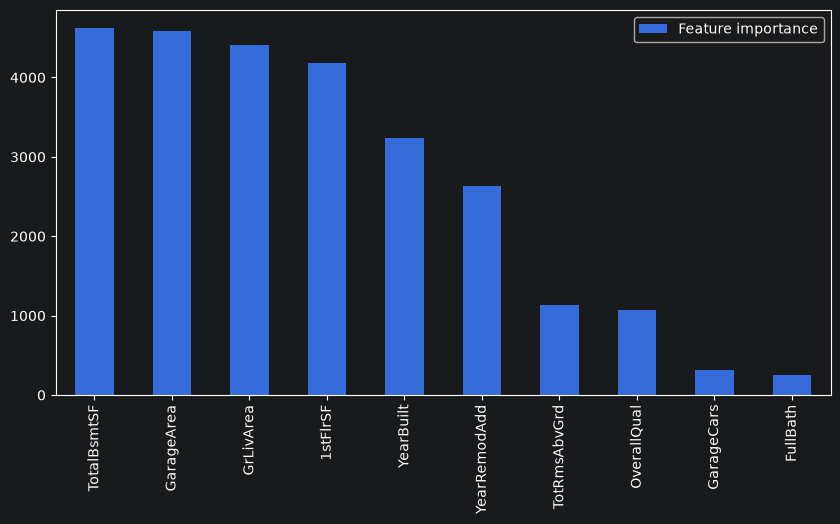

In [41]:
# feature importance (split)
feat_imp = pd.DataFrame(index=X_train.columns,columns=['Feature importance'],data=lgbm_opt.feature_importance(importance_type="split"))
feat_imp = feat_imp.sort_values(by='Feature importance',ascending=False)
feat_imp.plot.bar(figsize=(10,5));

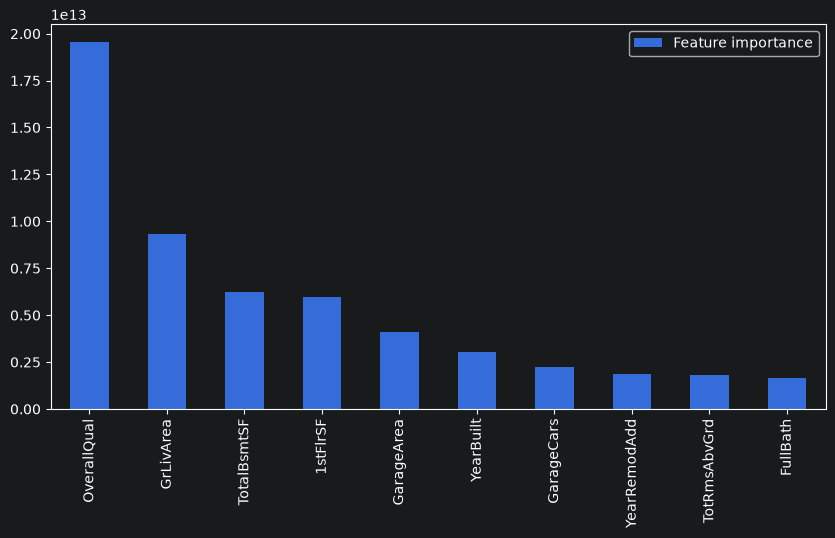

In [42]:
# feature importance (gain)
feat_imp = pd.DataFrame(index=X_train.columns,columns=['Feature importance'],data=lgbm_opt.feature_importance(importance_type="gain"))
feat_imp = feat_imp.sort_values(by='Feature importance',ascending=False)
feat_imp.plot.bar(figsize=(10,5));



_University of Zagreb Faculty of Electrical Engineering and Computing_  
_Laboratory for Renewable Energy Systems_  

_Course: AI bootcamp - Foundations of AI_ \
_Notebook: 3c_Hyperparameter_search_

_Website: [www.lares.fer.hr](https://www.lares.fer.hr/)_  
_Contact: [Hrvoje Novak](mailto:hrvoje.novak@fer.hr)_

